<a href="https://colab.research.google.com/github/jmmarinr/ComputationalMethods/blob/master/EDO/Euler_Vectorial_RK2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
#@title Librerias

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp, odeint
plt.style.use('classic')

# Método de Euler para EDOs de Segundo Orden: Formulación Matricial

---

**Prof. Juan Marcos Marín Ramírez**

---

Cuando trabajamos con ecuaciones diferenciales de segundo orden o con sistemas de ecuaciones diferenciales, la notación matricial proporciona una forma elegante y compacta de expresar tanto el sistema como el método numérico.

Consideremos una ecuación diferencial de segundo orden en su forma general:

$$\frac{d^2y}{dx^2} = f\left(x, y, \frac{dy}{dx}\right)$$

La transformamos en un sistema de primer orden definiendo un vector de estado:

$$\mathbf{Y} = \begin{bmatrix} y_1 \\ y_2 \end{bmatrix} = \begin{bmatrix} y \\ \frac{dy}{dx} \end{bmatrix}$$

La derivada de este vector será:

$$\frac{d\mathbf{Y}}{dx} = \begin{bmatrix} \frac{dy_1}{dx} \\ \frac{dy_2}{dx} \end{bmatrix} = \begin{bmatrix} y_2 \\ f(x, y_1, y_2) \end{bmatrix} = \mathbf{F}(x, \mathbf{Y})$$

# Método de Euler para EDOs de Orden Superior

Cuando se trabaja con ecuaciones diferenciales de orden superior, se puede reformular el problema como un sistema de primer orden. Esta transformación permite aplicar métodos numéricos estándar como el método de Euler explícito.

## Planteamiento general

Sea una ecuación diferencial ordinaria (EDO) de orden arbitrario $m$:

$$
\frac{d^m y}{dx^m} = f\left(x, y, \frac{dy}{dx}, \frac{d^2 y}{dx^2}, \dots, \frac{d^{m-1} y}{dx^{m-1}}\right)
$$

Definimos el **vector de estado** $\mathbf{Y}(x)$ como:

$$
\mathbf{Y}(x) =
\begin{bmatrix}
y(x) \\
y'(x) \\
y''(x) \\
\vdots \\
y^{(m-1)}(x)
\end{bmatrix}
$$

La derivada del vector de estado se expresa como:

$$
\frac{d\mathbf{Y}}{dx} =
\begin{bmatrix}
y'(x) \\
y''(x) \\
\vdots \\
y^{(m)}(x)
\end{bmatrix}
=
\begin{bmatrix}
Y_1 \\
Y_2 \\
\vdots \\
f(x, Y_0, Y_1, \dots, Y_{m-1})
\end{bmatrix}
$$

donde $Y_k$ denota la $k$-ésima componente del vector $\mathbf{Y}$, es decir, $Y_0 = y$, $Y_1 = y'$, y así sucesivamente.

## Método de Euler

Dado un paso $h > 0$ y un punto inicial $x_0$, el método de Euler explícito aplicado a este sistema es:

$$
\mathbf{Y}_{n+1} = \mathbf{Y}_n + h \cdot \frac{d\mathbf{Y}}{dx}(x_n, \mathbf{Y}_n)
$$

Esto equivale a la actualización componente a componente:

$$
\begin{aligned}
Y_0^{(n+1)} &= Y_0^{(n)} + h\, Y_1^{(n)} \\
Y_1^{(n+1)} &= Y_1^{(n)} + h\, Y_2^{(n)} \\
&\ \ \vdots \\
Y_{m-2}^{(n+1)} &= Y_{m-2}^{(n)} + h\, Y_{m-1}^{(n)} \\
Y_{m-1}^{(n+1)} &= Y_{m-1}^{(n)} + h\, f(x_n, Y_0^{(n)}, \dots, Y_{m-1}^{(n)})
\end{aligned}
$$

## Condiciones iniciales

Las condiciones iniciales deben proporcionarse en forma de vector:

$$
\mathbf{Y}_0 =
\begin{bmatrix}
y(x_0) \\
y'(x_0) \\
\vdots \\
y^{(m-1)}(x_0)
\end{bmatrix}
$$

Este vector actúa como punto de arranque para la integración numérica.




In [17]:
def Euler_OrdenSuperior(f, t0, tf, Y0, h):
    '''
    Resuelve una ecuación diferencial de orden superior usando el método de Euler explícito.

    Parámetros:
    ----------
    f : callable
        Función que define el sistema de primer orden: f(t, Y) devuelve dY/dt.
        Se asume que Y contiene las derivadas [y, y', y'', ..., y^{(m-1)}].

    t0 : float
        Tiempo inicial.

    tf : float
        Tiempo final.

    Y0 : array_like
        Vector de condiciones iniciales. Ejemplo: [y0, y0', y0'', ..., y0^{(m-1)}].

    h : float
        Tamaño del paso de integración.

    Retorna:
    -------
    t : ndarray, shape (N,)
        Arreglo con los puntos de tiempo: t[0] = t0, t[1] = t0 + h, ..., t[-1] = tf.

    Yn : ndarray, shape (m, N)
        Matriz donde cada fila corresponde a una derivada:
        - Yn[0, :] ≈ y(t)
        - Yn[1, :] ≈ y'(t)
        - ...
        - Yn[m-1, :] ≈ y^{(m-1)}(t)
    '''

    # Número total de pasos de integración (nodos)
    nodos = int((tf - t0) / h)

    # Orden del sistema (dimensión del vector de estado Y)
    m = len(Y0)

    # Arreglo de tiempos con nodos+1 puntos
    t = np.zeros(nodos + 1)

    # Matriz para guardar las soluciones:
    # Cada fila es una derivada, cada columna es un instante de tiempo
    Yn = np.zeros((m, nodos + 1))

    # Condiciones iniciales
    t[0] = t0
    Yn[:, 0] = Y0

    # Iteración del método de Euler
    for k in range(nodos):
        t[k + 1] = t[k] + h                           # Paso en el tiempo
        Yn[:, k + 1] = Yn[:, k] + h * f(t[k], Yn[:, k])  # Paso de Euler

    return t, Yn


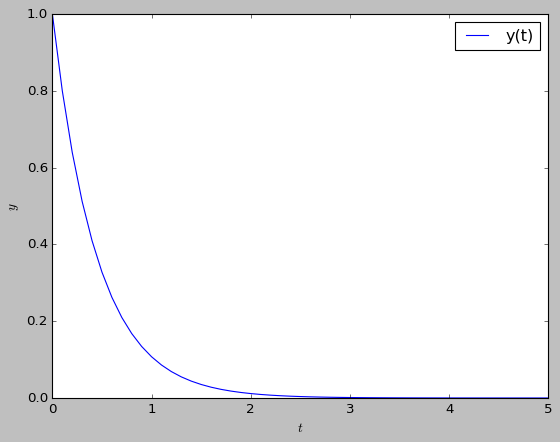

In [18]:
# Definición del sistema (orden 1): y' = -2y
def f(t, Y):
  dYdt = np.zeros_like(Y, dtype= float)
  dYdt[0] = -2*Y[0]
  return dYdt

# Condiciones iniciales
t0 = 0
tf = 5
h = 0.1
Y0 = [1.0]  # y(0) = 1

# Resolver usando Euler_OrdenSuperior
t, Yn = Euler_OrdenSuperior(f, t0, tf, Y0, h)

plt.plot(t, Yn[0,:], label='y(t)')
plt.legend()
plt.xlabel('$t$')
plt.ylabel('$y$')
plt.legend()
plt.show()

In [19]:
# y'' + 4y = 0  →  y'' = -4y
# Sistema: Y = [y, y'], entonces f(t, Y) = [y', -4y]

def f(t, Y):
  dYdt = np.zeros_like(Y, dtype= float)
  dYdt[0] = Y[1]
  dYdt[1] = -4*Y[0]
  return dYdt

t0 = 0
tf = 10
h = 0.001
Y0 = [1.0, 0.0]  # y(0) = 1, y'(0) = 0

t, Yn = Euler_OrdenSuperior(f, t0, tf, Y0, h)

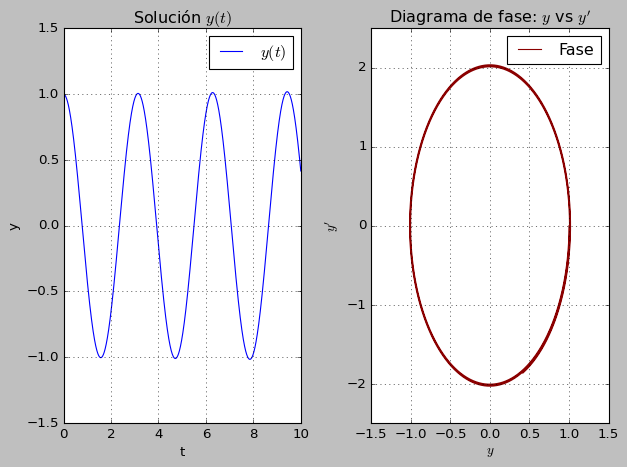

In [20]:

# y(t)
plt.subplot(1, 2, 1)
plt.plot(t, Yn[0,:], label='$y(t)$', color='blue')
plt.title('Solución $y(t)$')
plt.xlabel('t')
plt.ylabel('y')
plt.grid(True)
plt.legend()

# Diagrama de fase
plt.subplot(1, 2, 2)
plt.plot(Yn[0,:], Yn[1,:], label='Fase', color='darkred')
plt.title('Diagrama de fase: $y$ vs $y\'$')
plt.xlabel('$y$')
plt.ylabel('$y\'$')
plt.grid(True)
plt.axis('equal')
plt.legend()

plt.tight_layout()
plt.show()


In [21]:
# Ejemplo: Oscilador armónico amortiguado con fuerza externa
# Ecuación: y''' + 0.5y'' + 4y' + 0.3y = 2*cos(t)
#
# Definimos:
# y₁ = y
# y₂ = y'
# y₃ = y''
#
# Sistema de primer orden:
# y₁' = y₂
# y₂' = y₃
# y₃' = 2*cos(t) - 0.3*y₁ - 4*y₂ - 0.5*y₃

def oscilador_amortiguado_forzado(t, y):
    """
    Función que define el sistema de EDOs para un oscilador amortiguado con fuerza externa.

    Parámetros:
    t -- tiempo
    y -- vector de estado [y, y', y'']

    Retorna:
    dydt -- vector con las derivadas [y', y'', y''']
    """
    dydt = np.zeros_like(y, dtype=float)
    # y' = y₂
    dydt[0] = y[1]
    # y'' = y₃
    dydt[1] = y[2]
    # y''' = 2*cos(t) - 0.3*y - 4*y' - 0.5*y''
    dydt[2] = 2*np.cos(t) - 0.3*y[0] - 4*y[1] - 0.5*y[2]

    return dydt

In [22]:
# Condiciones iniciales
y0 = np.array([0.0, 0.0, 0.0])  # y(0) = 0, y'(0) = 0, y''(0) = 0
t0, tf = 0., 30.                  # Intervalo de tiempo [0, 30]
h = 0.01                        # Tamaño de paso

# Aplicar el método de Euler
t, y = Euler_OrdenSuperior(oscilador_amortiguado_forzado, t0, tf, y0, h)

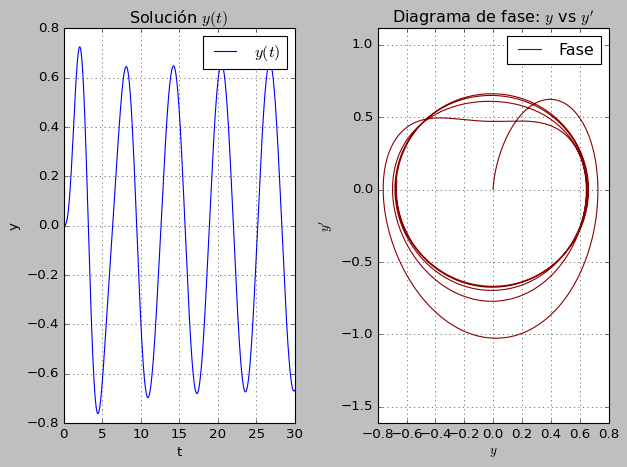

In [23]:

# y(t)
plt.subplot(1, 2, 1)
plt.plot(t, y[0,:], label='$y(t)$', color='blue')
plt.title('Solución $y(t)$')
plt.xlabel('t')
plt.ylabel('y')
plt.grid(True)
plt.legend()

# Diagrama de fases
plt.subplot(1, 2, 2)
plt.plot(y[0,:], y[1,:], label='Fase', color='darkred')
plt.title('Diagrama de fase: $y$ vs $y\'$')
plt.xlabel('$y$')
plt.ylabel('$y\'$')
plt.grid(True)
plt.axis('equal')
plt.legend()

plt.tight_layout()
plt.show()

# Métodos Numéricos: Runge-Kutta de Segundo Orden

Los algoritmos de Runge-Kutta son particularmente importantes para resolver ecuaciones diferenciales ordinarias (EDOs). Dentro de estos, tenemos el método de Runge-Kutta de segundo orden (RK2), también conocido como método de Heun o método del punto medio. Este método proporciona una aproximación más precisa que el método de Euler, manteniendo una complejidad computacional razonable.


Consideremos una ecuación diferencial ordinaria de primer orden con un valor inicial:

$$\frac{dy}{dx} = f(x, y), \quad y(x_0) = y_0$$

Nuestro objetivo es encontrar una aproximación numérica de $y(x)$ en un conjunto discreto de puntos $x_0, x_1, x_2, ..., x_n$.

## Método de Euler

Antes de abordar el método RK2, recordemos el método más simple, el método de Euler:

$$y_{n+1} = y_n + h \cdot f(x_n, y_n)$$

donde $h = x_{n+1} - x_n$ es el tamaño del paso.

El método de Euler utiliza solamente la información de la pendiente al inicio del intervalo, lo que lo hace simple pero relativamente impreciso.

## Método de Runge-Kutta de Segundo Orden (RK2)

El método RK2 mejora la precisión al utilizar una combinación ponderada de dos evaluaciones de la función $f(x, y)$ en diferentes puntos del intervalo. La fórmula general es:

$$y_{n+1} = y_n + h \cdot (a_1 k_1 + a_2 k_2)$$

Donde:
- $k_1 = f(x_n, y_n)$ (pendiente al inicio del intervalo)
- $k_2 = f(x_n + p_1 h, y_n + p_2 h k_1)$ (pendiente en un punto intermedio o al final)
- $a_1, a_2, p_1, p_2$ son parámetros que definen el método específico

Para que el método sea de segundo orden, estos parámetros deben satisfacer ciertas condiciones:
- $a_1 + a_2 = 1$ (consistencia)
- $a_2 p_1 = \frac{1}{2}$ (condición de orden 2)
- $a_2 p_2 = \frac{1}{2}$

Existen varias variantes del método RK2, dependiendo de la elección de estos parámetros.

### Método del Punto Medio (Midpoint Method)

En el método del punto medio, usamos:
- $a_1 = 0, a_2 = 1, p_1 = \frac{1}{2}, p_2 = \frac{1}{2}$

Lo que nos da:
- $k_1 = f(x_n, y_n)$
- $k_2 = f(x_n + \frac{h}{2}, y_n + \frac{h}{2} k_1)$
- $y_{n+1} = y_n + h \cdot k_2$

Este método evalúa la función en el punto medio del intervalo, utilizando la pendiente inicial para llegar a ese punto.

### Método de Heun

En el método de Heun, usamos:
- $a_1 = \frac{1}{2}, a_2 = \frac{1}{2}, p_1 = 1, p_2 = 1$

Lo que nos da:
- $k_1 = f(x_n, y_n)$
- $k_2 = f(x_n + h, y_n + h k_1)$
- $y_{n+1} = y_n + \frac{h}{2} \cdot (k_1 + k_2)$

Este método es esencialmente un promedio entre la pendiente al inicio y al final del intervalo.

### Método de Ralston (Ralston's Method)

En el método de Ralston, usamos:
- $a_1 = \frac{1}{4}, a_2 = \frac{3}{4}, p_1 = \frac{2}{3}, p_2 = \frac{2}{3}$

Lo que nos da:
- $k_1 = f(x_n, y_n)$
- $k_2 = f(x_n + \frac{2h}{3}, y_n + \frac{2h}{3} k_1)$
- $y_{n+1} = y_n + h \cdot (\frac{1}{4}k_1 + \frac{3}{4}k_2)$

Este método está optimizado para minimizar el error de truncamiento.

## Análisis de Error

El método de Euler tiene un error local de truncamiento de orden $O(h^2)$ y un error global de orden $O(h)$.

El método RK2, en cualquiera de sus variantes, tiene un error local de truncamiento de orden $O(h^3)$ y un error global de orden $O(h^2)$, lo que lo hace significativamente más preciso que el método de Euler.

### Ejemplo

Consideremos la ecuación diferencial:

$$\frac{dy}{dx} = y, \quad y(0) = 1$$

La solución analítica de esta ecuación es $y(x) = e^x$.

Vamos a calcular $y(0.1)$ y $y(0.2)$ utilizando un tamaño de paso $h = 0.1$ con ambos métodos.

### Solución Analítica en los Primeros Puntos

- $y(0) = e^0 = 1$
- $y(0.1) = e^{0.1} \approx 1.10517$
- $y(0.2) = e^{0.2} \approx 1.22140$

### Solución con el Método del Punto Medio

**Paso 1**: Calcular $y(0.1)$ dado $y(0) = 1$

$$k_1 = f(0, 1) = 1$$
$$k_2 = f(0 + \frac{0.1}{2}, 1 + \frac{0.1}{2} \cdot 1) = f(0.05, 1.05) = 1.05$$
$$y(0.1) = 1 + 0.1 \cdot 1.05 = 1 + 0.105 = 1.105$$

**Paso 2**: Calcular $y(0.2)$ dado $y(0.1) = 1.105$

$$k_1 = f(0.1, 1.105) = 1.105$$
$$k_2 = f(0.1 + \frac{0.1}{2}, 1.105 + \frac{0.1}{2} \cdot 1.105) = f(0.15, 1.16025) = 1.16025$$
$$y(0.2) = 1.105 + 0.1 \cdot 1.16025 = 1.105 + 0.116025 = 1.22103$$

### Solución con el Método de Heun

**Paso 1**: Calcular $y(0.1)$ dado $y(0) = 1$

$$k_1 = f(0, 1) = 1$$
$$k_2 = f(0 + 0.1, 1 + 0.1 \cdot 1) = f(0.1, 1.1) = 1.1$$
$$y(0.1) = 1 + \frac{0.1}{2} \cdot (1 + 1.1) = 1 + 0.05 \cdot 2.1 = 1 + 0.105 = 1.105$$

**Paso 2**: Calcular $y(0.2)$ dado $y(0.1) = 1.105$

$$k_1 = f(0.1, 1.105) = 1.105$$
$$k_2 = f(0.1 + 0.1, 1.105 + 0.1 \cdot 1.105) = f(0.2, 1.2155) = 1.2155$$
$$y(0.2) = 1.105 + \frac{0.1}{2} \cdot (1.105 + 1.2155) = 1.105 + 0.05 \cdot 2.3205 = 1.105 + 0.116025 = 1.22103$$

### Comparación con la Solución Analítica
| $x$ | Solución Analítica | Punto Medio | Error Punto Medio | Heun | Error Heun |
|-----|-------------------|-------------|------------------|------|------------|
| 0.0 | 1.00000 | 1.00000 | 0.00000 | 1.00000 | 0.00000 |
| 0.1 | 1.10517 | 1.10500 | 0.00017 | 1.10500 | 0.00017 |
| 0.2 | 1.22140 | 1.22103 | 0.00037 | 1.22103 | 0.00037 |

Interesantemente, para este ejemplo particular, ambos métodos arrojan exactamente el mismo resultado.

In [24]:
def RK2_PuntoMedio(f, t0, tf, Y0, h):
    '''
    Método de Runge-Kutta de segundo orden (punto medio) para sistemas de EDOs.

    Parámetros:
    ----------
    f : callable
        Función que define el sistema de primer orden: f(t, Y) → dY/dt.
        Debe aceptar un escalar t y un vector Y con las derivadas [y, y', ..., y^{(m-1)}].

    t0 : float
        Tiempo inicial.

    tf : float
        Tiempo final.

    Y0 : array_like
        Vector de condiciones iniciales. Ejemplo: [y0, y0', ..., y0^{(m-1)}].

    h : float
        Tamaño del paso de integración.

    Retorna:
    -------
    t : ndarray, shape (N,)
        Vector de tiempos: t[0] = t0, ..., t[-1] = tf.

    Y : ndarray, shape (m, N)
        Matriz de soluciones. Cada fila representa una derivada:
        - Y[0, :] ≈ y(t)
        - Y[1, :] ≈ y'(t)
        - ...
        - Y[m-1, :] ≈ y^{(m-1)}(t)
    '''

    # Número total de pasos de integración
    nodos = int((tf - t0) / h)

    # Orden del sistema (longitud del vector Y0)
    m = len(Y0)

    # Inicialización del vector de tiempos
    t = np.zeros(nodos + 1)

    # Inicialización de la matriz solución:
    # filas: derivadas [y, y', ..., y^{(m-1)}]; columnas: instantes de tiempo
    Y = np.zeros((m, nodos + 1))

    # Asignar condiciones iniciales
    t[0] = t0        # Tiempo inicial
    Y[:, 0] = Y0     # Estado inicial (vector de derivadas)

    # Iteración principal del método de Runge-Kutta de segundo orden
    for k in range(nodos):
        t[k + 1] = t[k] + h  # Avanza el tiempo al siguiente paso

        # Primer estimador de pendiente: en el punto inicial
        k1 = f(t[k], Y[:, k])

        # Segundo estimador: evalúa en el punto medio con k1
        k2 = f(t[k] + h/2, Y[:, k] + h/2 * k1)

        # Actualización del estado con el segundo estimador (punto medio)
        Y[:, k + 1] = Y[:, k] + h * k2

    return t, Y

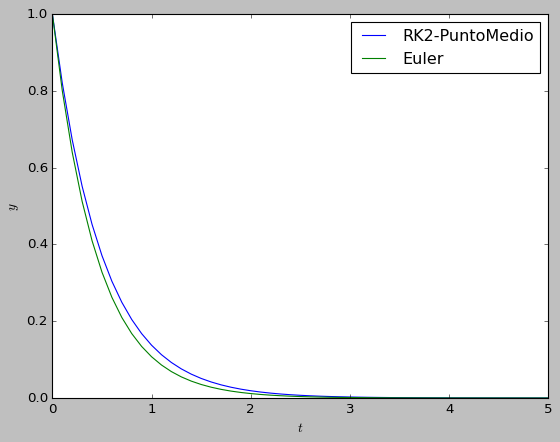

In [25]:
# Definición del sistema (orden 1): y' = -2y
def f(t, Y):
  dYdt = np.zeros_like(Y, dtype= float)
  dYdt[0] = -2*Y[0]
  return dYdt

# Condiciones iniciales
t0 = 0
tf = 5
h = 0.1
Y0 = [1.0]  # y(0) = 1

# Resolver usando Euler
t_Euler, Yn_Euler = Euler_OrdenSuperior(f, t0, tf, Y0, h)

# Resolver usando RK2-PuntoMedio
t, Yn = RK2_PuntoMedio(f, t0, tf, Y0, h)

plt.plot(t, Yn[0,:], label = 'RK2-PuntoMedio')
plt.plot(t_Euler, Yn_Euler[0,:], label = 'Euler')
plt.legend()
plt.xlabel('$t$')
plt.ylabel('$y$')
plt.legend()
plt.show()

In [26]:
# y'' + 4y = 0  →  y'' = -4y
# Sistema: Y = [y, y'], entonces f(t, Y) = [y', -4y]

def f(t, Y):
  dYdt = np.zeros_like(Y, dtype= float)
  dYdt[0] = Y[1]
  dYdt[1] = -4*Y[0]
  return dYdt

t0 = 0
tf = 10
h = 0.1
Y0 = [1.0, 0.0]  # y(0) = 1, y'(0) = 0

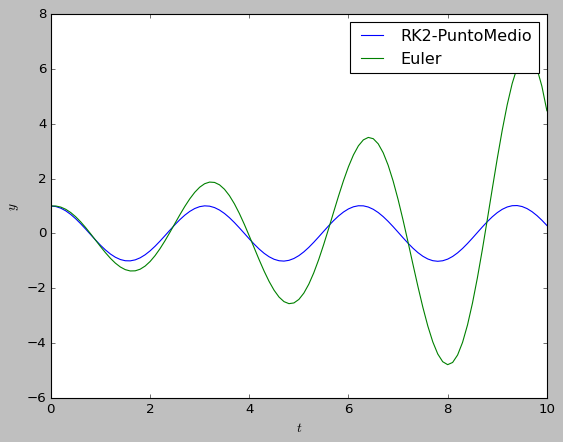

In [27]:
# @title
t_Euler, Yn_Euler = Euler_OrdenSuperior(f, t0, tf, Y0, h)
t, Yn = RK2_PuntoMedio(f, t0, tf, Y0, h)

plt.plot(t, Yn[0,:], label = 'RK2-PuntoMedio')
plt.plot(t_Euler, Yn_Euler[0,:], label = 'Euler')
plt.xlabel('$t$')
plt.ylabel('$y$')
plt.legend()
plt.show()

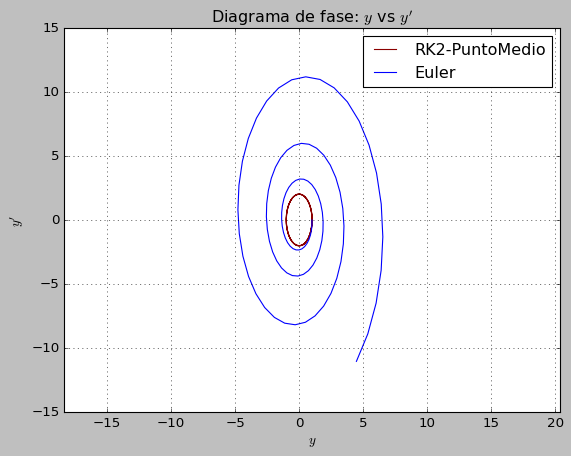

In [28]:
plt.plot(Yn[0,:], Yn[1,:], label='RK2-PuntoMedio', color='darkred')
plt.plot(Yn_Euler[0,:], Yn_Euler[1,:], label='Euler', color='blue')
plt.title('Diagrama de fase: $y$ vs $y\'$')
plt.xlabel('$y$')
plt.ylabel('$y\'$')
plt.grid(True)
plt.axis('equal')
plt.legend()

plt.show()

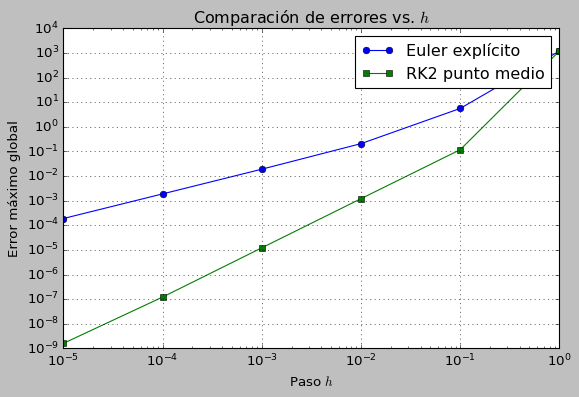

In [29]:
# Solución exacta para comparación
def y_exacta(t):
    return np.cos(2 * t)


# Comparar errores para distintos valores de h
t0, tf = 0, 10
Y0 = [1.0, 0.0]
h_values = np.logspace(-5, 0, 6)
errors_euler = []
errors_rk2 = []



for h in h_values:
    # Euler
    t_euler, Y_euler = Euler_OrdenSuperior(f, t0, tf, Y0, h)
    y_exact_interp = y_exacta(t_euler)
    error_euler = np.max(np.abs(Y_euler[0, :] - y_exact_interp))
    errors_euler.append(error_euler)

    # RK2
    t_rk2, Y_rk2 = RK2_PuntoMedio(f, t0, tf, Y0, h)
    y_exact_interp = y_exacta(t_rk2)
    error_rk2 = np.max(np.abs(Y_rk2[0, :] - y_exact_interp))
    errors_rk2.append(error_rk2)

# Gráfico de errores
plt.figure(figsize=(8, 5))
plt.loglog(h_values, errors_euler, 'o-', label='Euler explícito')
plt.loglog(h_values, errors_rk2, 's-', label='RK2 punto medio')
plt.xlabel('Paso $h$')
plt.ylabel('Error máximo global')
plt.title('Comparación de errores vs. $h$')
plt.grid(True)
plt.legend()
plt.show()